# Attribution: mechanisms against the hard core

One row per unit of the two cores, the under-reported and the over-reported, with
a verdict for each mechanism tested and a `probable_cause` in output. The rules
are deliberately simple and stated in full, so a reader can disagree with a
threshold rather than with a black box.

| Mechanism | Source | Rule |
|---|---|---|
| Fragmentation | `2_eld.ipynb`, share of detected PV in non-incumbent territory | at least 33% gives `ELD`; at least 10% gives `ELD-partial` |
| Connection lag, downstream | `temporal_lag_departements.csv`, 18 of 18 not temporal | borderline when the three-month transit reaches 80% of the gap, which happens once |
| Administrative anticipation, upstream | `temporal_lag_above_departements.csv`, 7 of 7 not temporal | — |
| Declaration behaviour | tested on a nine-unit pilot and inconclusive (rho +0.15, p 0.70). Exploratory, outside the main analysis, and not part of this release |
| Conversion coefficient | the `conversion_sensitive` flag from the battery | a fragility, not a cause |

The `unexplained` units are the paper's conclusion rather than its leftovers.
Neither distribution-chain fragmentation, nor connection lag bounded in both
directions, nor any observable declaration behaviour accounts for them.
Genuine non-reporting cannot be ruled out.

In [1]:
import sys
from pathlib import Path
import geopandas as gpd
import numpy as np
import pandas as pd

def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
import units

rb = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})
lag_b = pd.read_csv(paths.TEMPORAL_LAG, dtype={'dpt': str})
lag_a = pd.read_csv(paths.TEMPORAL_LAG_ABOVE, dtype={'dpt': str})

# Share of detected PV in ELD-served municipalities, per unit. Same computation as 2_eld.ipynb.
cp = gpd.read_file(paths.OPERATOR_BY_MUNICIPALITY, ignore_geometry=True)
cp['insee'] = cp['insee'].astype(str).str.zfill(5)
cc = pd.read_csv(paths.COMPARISON_COMMUNES,
                 dtype={'code_insee': str, 'dpt': str})
com = cc.merge(cp[['insee', 'categorie']], left_on='code_insee', right_on='insee', how='left')
com['unit'] = units.to_unit(com['dpt'])
com['is_eld'] = np.where(com['categorie'] == 'Enedis', 0,
                np.where(com['categorie'] == 'Autre distributeur', 1, np.nan))
share = (com[com.is_eld.notna()]
         .assign(pv_eld=lambda d: d.kWp_dpvm * d.is_eld)
         .groupby('unit')
         .agg(pv=('kWp_dpvm', 'sum'), pv_eld=('pv_eld', 'sum')))
share['share_eld_pv'] = share.pv_eld / share.pv
rb = rb.merge(share[['share_eld_pv']].reset_index(), left_on='dpt', right_on='unit', how='left')
print('fragmentation exposure loaded')

fragmentation exposure loaded


In [2]:
# --- BELOW ---
hcb = rb[rb['hard_core_below']].copy() if 'hard_core_below' in rb.columns else \
      rb[(rb.status_A == 'below') & (rb.status_B == 'below')].copy()
hcb['gap_MWc'] = (hcb.p_inst_mean - hcb.kWp_rte) / 1e3
hcb = hcb.merge(lag_b[['dpt', 'transit_k3_MWc', 'temporal_k_realistic']], on='dpt', how='left')
hcb['temporal'] = np.where(hcb.transit_k3_MWc >= 0.8 * hcb.gap_MWc, 'borderline', 'ruled out')
hcb['eld'] = np.where(hcb.share_eld_pv >= 1/3, 'ELD',
             np.where(hcb.share_eld_pv >= 0.10, 'ELD-partial', '—'))
def cause_below(r):
    base = {'ELD': 'ELD', 'ELD-partial': 'ELD (partial) + unexplained', '—': 'unexplained'}[r.eld]
    frag = []
    if r.conversion_sensitive: frag.append('conv-sensitive')
    if r.temporal == 'borderline': frag.append('temporal-borderline')
    return base + (f"  [{', '.join(frag)}]" if frag else '')
hcb['probable_cause'] = hcb.apply(cause_below, axis=1)
cols = ['dpt', 'nom', 'gap_MWc', 'share_eld_pv', 'temporal', 'probable_cause']
tb = hcb[cols].sort_values('gap_MWc', ascending=False)
print(tb.to_string(index=False, float_format=lambda v: f'{v:.2f}'))
print()
agg = hcb.groupby(hcb.probable_cause.str.split(' ').str[0]).agg(n=('dpt', 'size'), MWc=('gap_MWc', 'sum'))
print(agg.round(1).to_string())

 dpt                     nom  gap_MWc  share_eld_pv   temporal                                     probable_cause
  79             Deux-Sèvres    36.01          0.97  ruled out                                                ELD
  24                Dordogne    14.98          0.00  ruled out                                        unexplained
  13        Bouches-du-Rhône    12.45          0.00 borderline unexplained  [conv-sensitive, temporal-borderline]
  19                 Corrèze    11.69          0.00  ruled out                                        unexplained
75PC Paris + petite couronne    11.17          0.00  ruled out                                        unexplained
  28            Eure-et-Loir    10.89          0.27  ruled out                        ELD (partial) + unexplained
  86                  Vienne    10.25          0.85  ruled out                                                ELD
  88                  Vosges     9.73          0.02  ruled out                      unex

In [3]:
# --- ABOVE ---
hca = rb[rb['hard_core_above']].copy() if 'hard_core_above' in rb.columns else \
      rb[(rb.status_A == 'above') & (rb.status_B == 'above')].copy()
hca['gap_MWc'] = (hca.kWp_rte - hca.p_inst_mean) / 1e3
hca = hca.merge(lag_a[['dpt', 'temporal_k_realistic']], on='dpt', how='left')
def cause_above(r):
    if r.conversion_sensitive:
        return 'conversion-sensitive'
    return 'unexplained (local recall / registry-side, untested)'
hca['probable_cause'] = hca.apply(cause_above, axis=1)
ta = hca[['dpt', 'nom', 'gap_MWc', 'temporal_k_realistic', 'probable_cause']].sort_values('gap_MWc', ascending=False)
print(ta.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

dpt                nom  gap_MWc temporal_k_realistic                                       probable_cause
 31      Haute-Garonne    27.19         not_temporal unexplained (local recall / registry-side, untested)
 54 Meurthe-et-Moselle    12.50         not_temporal unexplained (local recall / registry-side, untested)
 81               Tarn    11.89         not_temporal                                 conversion-sensitive
 27               Eure     9.39         not_temporal unexplained (local recall / registry-side, untested)
 50             Manche     9.19         not_temporal unexplained (local recall / registry-side, untested)
 37     Indre-et-Loire     8.51         not_temporal                                 conversion-sensitive
 89              Yonne     4.53         not_temporal unexplained (local recall / registry-side, untested)


In [4]:
# export
out = pd.concat([
    hcb[['dpt', 'nom', 'gap_MWc', 'share_eld_pv', 'temporal', 'conversion_sensitive', 'probable_cause']]
        .assign(side='below'),
    hca[['dpt', 'nom', 'gap_MWc', 'conversion_sensitive', 'probable_cause']].assign(side='above'),
], ignore_index=True)
out.to_csv(paths.TAGGING, index=False)
print(f"Ecrit : mechanisms_tagging.csv ({len(out)} unites)")

Ecrit : mechanisms_tagging.csv (25 unites)


## Map of the unexplained residual

This is the paper's central claim in one image: the national totals agree, and
locally there are gaps that neither fragmentation nor timing accounts for.

Units of the two cores. Green where fragmentation explains the gap. The rest
coloured by direction, blue where capacity is missing from the registry, red
where the registry exceeds the estimate, with intensity given by the share of the
local corrected fleet.

RESIDU INEXPLIQUE — below : 12 unites, 95 MWc manquants (part locale mediane 27%, max 40%)
 dpt                     nom  gap_MWc  share_local
  24                Dordogne    14.98         0.28
  13        Bouches-du-Rhône    12.45         0.14
  19                 Corrèze    11.69         0.40
75PC Paris + petite couronne    11.17         0.32
  88                  Vosges     9.73         0.21
  15                  Cantal     7.05         0.25
  23                  Creuse     6.40         0.36
  48                  Lozère     5.93         0.37
  14                Calvados     4.66         0.24
  61                    Orne     4.19         0.23
  55                   Meuse     4.16         0.22
  90   Territoire de Belfort     2.27         0.31

RESIDU INEXPLIQUE — above : 5 unites, 63 MWc excedentaires (part locale mediane 40%)
dpt                nom  gap_MWc  share_local
 31      Haute-Garonne    27.19         0.23
 54 Meurthe-et-Moselle    12.50         0.40
 27               Eure   

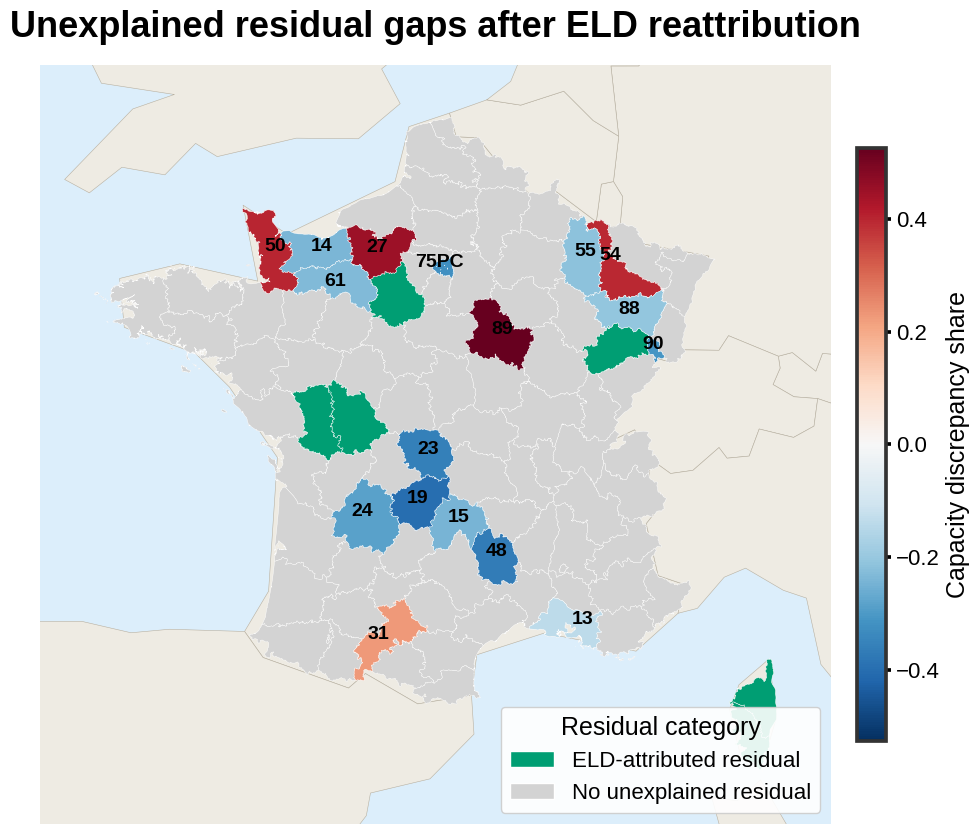

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import helpers, style

style.apply(fig_width_in=16)  # fonts scaled to the canvas width

FIGS_DIR = paths.FIGURES


# ---------------------------------------------------------
# Data
# ---------------------------------------------------------

geo = gpd.read_file(
    paths.RECALIBRATION
)[['dpt', 'geometry']]

geo['dpt'] = geo['dpt'].astype(str)


res_b = hcb[hcb.probable_cause.str.startswith('unexplained')].copy()
res_a = hca[hca.probable_cause.str.startswith('unexplained')].copy()
eld_u = hcb[hcb.probable_cause.str.startswith('ELD')].copy()


res_b['share_local'] = res_b.gap_MWc * 1e3 / res_b.p_inst_mean
res_a['share_local'] = res_a.gap_MWc * 1e3 / res_a.p_inst_mean


print(
    f"RESIDU INEXPLIQUE — below : {len(res_b)} unites, "
    f"{res_b.gap_MWc.sum():.0f} MWc manquants "
    f"(part locale mediane {res_b.share_local.median():.0%}, "
    f"max {res_b.share_local.max():.0%})"
)

print(
    res_b[['dpt', 'nom', 'gap_MWc', 'share_local']]
    .sort_values('gap_MWc', ascending=False)
    .to_string(index=False, float_format=lambda v: f'{v:.2f}')
)

print()

print(
    f"RESIDU INEXPLIQUE — above : {len(res_a)} unites, "
    f"{res_a.gap_MWc.sum():.0f} MWc excedentaires "
    f"(part locale mediane {res_a.share_local.median():.0%})"
)

print(
    res_a[['dpt', 'nom', 'gap_MWc', 'share_local']]
    .sort_values('gap_MWc', ascending=False)
    .to_string(index=False, float_format=lambda v: f'{v:.2f}')
)


# ---------------------------------------------------------
# Signed variable: negative under-reported, positive over-reported
# ---------------------------------------------------------

gap = pd.concat(
    [
        res_b[['dpt', 'share_local']]
        .assign(capacity_gap_share=lambda x: -x.share_local),

        res_a[['dpt', 'share_local']]
        .assign(capacity_gap_share=lambda x: x.share_local),
    ],
    ignore_index=True
)

gap = gap[['dpt', 'capacity_gap_share']]


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

helpers.add_basemap(ax, geo.total_bounds)

ax.set_aspect(
    1 / np.cos(np.radians(46.5))
)


# Base layer
geo.plot(
    ax=ax,
    color='lightgray',
    edgecolor='white',
    linewidth=0.3,
    zorder=1
)


# ---------------------------------------------------------
# ELD
# ---------------------------------------------------------

ge = geo.merge(
    eld_u[['dpt']],
    on='dpt'
)

ge.plot(
    ax=ax,
    color=style.OKABE_ITO['bluish_green'],
    edgecolor='white',
    linewidth=0.3,
    zorder=2
)


# ---------------------------------------------------------
# Carte divergente unique
# ---------------------------------------------------------

gflag = geo.merge(
    gap,
    on='dpt'
)


vmax = max(
    abs(gflag.capacity_gap_share).max(),
    0.3
)

norm = mcolors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)

cmap = plt.cm.RdBu_r


gflag.plot(
    ax=ax,
    column='capacity_gap_share',
    cmap=cmap,
    norm=norm,
    edgecolor='white',
    linewidth=0.3,
    zorder=2
)


# ---------------------------------------------------------
# Unit codes
# ---------------------------------------------------------

for _, r in gflag.iterrows():

    pt = r.geometry.representative_point()

    ax.annotate(
        r.dpt,
        (pt.x, pt.y),
        ha='center',
        fontsize=14,
        fontweight='bold',
        zorder=3
    )


helpers._hide_axis_chrome(ax)


# ---------------------------------------------------------
# One colorbar for the whole map
# ---------------------------------------------------------

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.03
)

cbar.set_label(
    'Capacity discrepancy share',
    fontsize=18
)

cbar.ax.tick_params(
    labelsize=16
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_elements = [
    Patch(
        facecolor=style.OKABE_ITO['bluish_green'],
        edgecolor='white',
        label='ELD-attributed residual'
    ),
    Patch(
        facecolor='lightgray',
        edgecolor='white',
        label='No unexplained residual'
    ),
]

ax.legend(
    handles=legend_elements,
    loc='lower right',
    fontsize=16,
    frameon=True,
    framealpha=0.9,
    title='Residual category',
    title_fontsize=18
)


# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

ax.set_title(
    'Unexplained residual gaps after ELD reattribution',
    fontsize=26,
    fontweight='bold',
    pad=20
)


plt.tight_layout()


helpers.save_fig(
    fig,
    'mechanisms_tagging_residual_map.pdf',
    FIGS_DIR
)

plt.show()

### Three-way plot

- The share served by local distributors, per unit
- Display the under-reporting units (25, incl. 18 hard-core with no alpha)
- Display the upper map (only for under-reporting units)


Fragmentation exposure of the over-reported units (negative control):
dpt                nom  share_eld_pv
 81               Tarn         0.063
 27               Eure         0.000
 31      Haute-Garonne         0.000
 37     Indre-et-Loire         0.000
 50             Manche         0.000
 54 Meurthe-et-Moselle         0.000
 89              Yonne         0.000
  -> above the 1/3 threshold      : 0 / 7
  -> above the 0.10 partial threshold : 0 / 7
  compare with the below core : 4 and 6 of 18



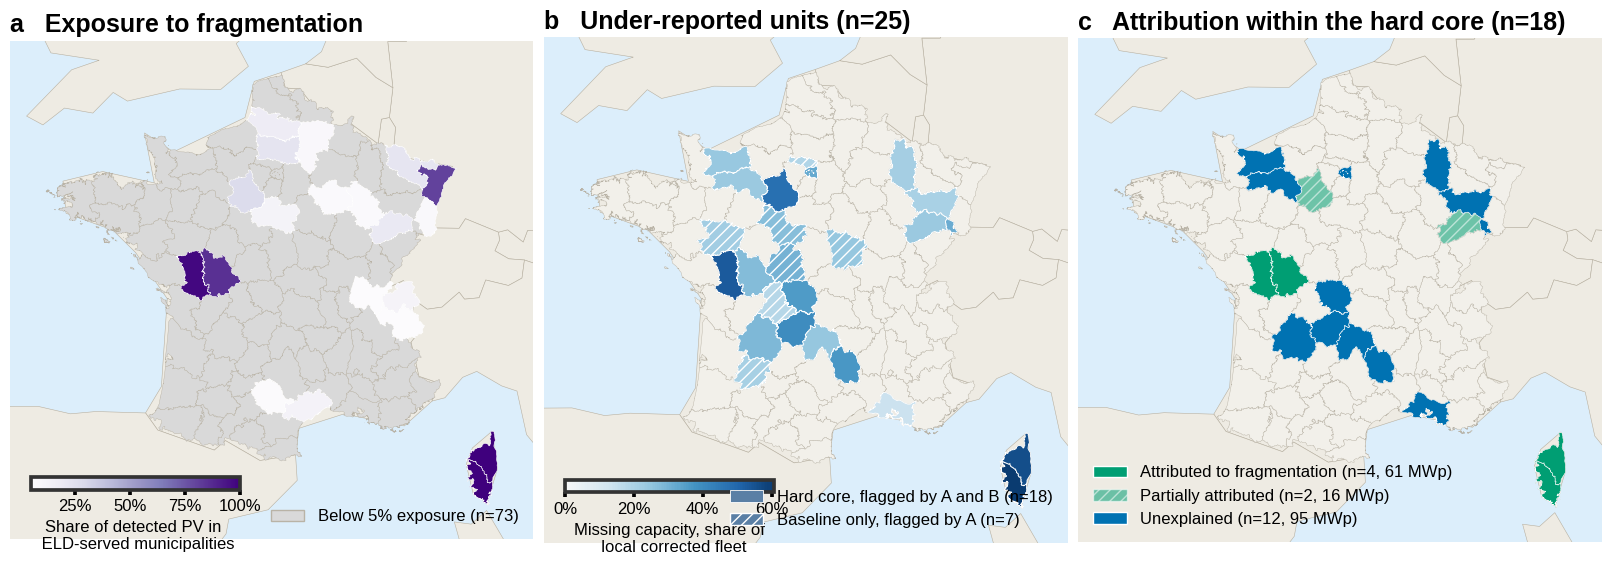

In [6]:
# =====================================================================
# Three-way plot: exposure -> flagged units -> attribution
# =====================================================================
# Font sizes
FONT_TITLE = 18
FONT_OTHER = 12

# The fragmentation label is applied only to under-reported units, by design:
# the mechanism is directional. Losing information as it crosses a reporting
# interface cannot produce a registry *surplus*.
#
# This cell checks that the restriction is also empirically empty, that is, that
# no unit of the negative control would have been tagged even if the rule had
# been applied to it. A design choice that happens to bind would be worth
# knowing about; this one does not.

import matplotlib.ticker as mticker

_above_chk = hca[['dpt', 'nom', 'share_eld_pv']].sort_values(
    'share_eld_pv', ascending=False
)
print("Fragmentation exposure of the over-reported units (negative control):")
print(_above_chk.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print(f"  -> above the 1/3 threshold      : {(hca.share_eld_pv >= 1/3).sum()} / {len(hca)}")
print(f"  -> above the 0.10 partial threshold : {(hca.share_eld_pv >= 0.10).sum()} / {len(hca)}")
print(f"  compare with the below core : {(hcb.share_eld_pv >= 1/3).sum()} and "
      f"{(hcb.share_eld_pv >= 0.10).sum()} of {len(hcb)}\n")

# ---------------------------------------------------------------------
# Data for the three panels
# ---------------------------------------------------------------------
C_ELD = style.OKABE_ITO['bluish_green']
C_BELOW = style.OKABE_ITO['blue']
C_BASE = '#f2f0ea'
C_EDGE = '#b9b3a6'

rb_map = rb[['dpt', 'share_eld_pv', 'status_A', 'hard_core_below',
             'p_inst_mean', 'kWp_rte']].copy()

# Gap as a share of the local corrected capacity, the same quantity as
# `share_local` on the residual map, and directly readable: x% of the local
# fleet is absent from the registry.
rb_map['gap_share'] = (
    rb_map.p_inst_mean - rb_map.kWp_rte
) / rb_map.p_inst_mean

gmap = geo.merge(rb_map, on='dpt', how='left')

below_A = gmap[gmap.status_A == 'below']
below_hc = below_A[below_A.hard_core_below]
below_only = below_A[~below_A.hard_core_below]

cause_map = hcb.set_index('dpt')['eld']  # 'ELD' / 'ELD-partial' / '—'
gcause = geo[geo.dpt.isin(cause_map.index)].copy()
gcause['eld'] = gcause.dpt.map(cause_map)

CAUSE_STYLE = {
    'ELD': (
        C_ELD, 1.00, None,
        'Attributed to fragmentation'
    ),
    'ELD-partial': (
        C_ELD, 0.55, '///',
        'Partially attributed'
    ),
    '—': (
        C_BELOW, 1.00, None,
        'Unexplained'
    ),
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 6.2),
    layout='constrained'
)

# ---- (a) exposure to fragmentation -----------------------------------
ax = axes[0]
EXPOSURE_FLOOR = 0.05

exposed = gmap[gmap.share_eld_pv >= EXPOSURE_FLOOR]
enedis_only = gmap[gmap.share_eld_pv < EXPOSURE_FLOOR]

helpers.add_basemap(ax, geo.total_bounds)

enedis_only.plot(
    ax=ax,
    facecolor='#d9d9d9',
    edgecolor=C_EDGE,
    linewidth=0.3,
    zorder=1
)

exposed.plot(
    ax=ax,
    column='share_eld_pv',
    cmap=style.CMAP_MAGNITUDE,
    vmin=EXPOSURE_FLOOR,
    vmax=1,
    edgecolor='white',
    linewidth=0.4,
    legend=False,
    zorder=2
)

sm = plt.cm.ScalarMappable(
    cmap=style.CMAP_MAGNITUDE,
    norm=mcolors.Normalize(vmin=EXPOSURE_FLOOR, vmax=1)
)

cax = ax.inset_axes([0.04, 0.10, 0.40, 0.025])

cb = fig.colorbar(
    sm,
    cax=cax,
    orientation='horizontal'
)

cb.set_label(
    'Share of detected PV in \n ELD-served municipalities',
    fontsize=FONT_OTHER
)

cb.ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0)
)

cb.ax.tick_params(
    labelsize=FONT_OTHER
)

ax.legend(
    handles=[
        Patch(
            facecolor='#d9d9d9',
            edgecolor=C_EDGE,
            label=(
                f'Below {EXPOSURE_FLOOR:.0%} exposure '
                f'(n={len(enedis_only)})'
            )
        )
    ],
    loc='lower right',
    fontsize=FONT_OTHER,
    frameon=False
)

ax.set_title(
    f'a   Exposure to fragmentation ',
    fontweight='bold',
    fontsize=FONT_TITLE,
    loc='left'
)

helpers._hide_axis_chrome(ax)


# ---- (b) under-reported units ----------------------------------------
ax = axes[1]

cmap_below = mcolors.LinearSegmentedColormap.from_list(
    'below_arm',
    plt.cm.RdBu_r(np.linspace(0.5, 0.02, 256))
)

vmax_gap = below_A.gap_share.max()
norm_gap = mcolors.Normalize(vmin=0, vmax=vmax_gap)

helpers.add_basemap(ax, geo.total_bounds)

gmap.plot(
    ax=ax,
    facecolor=C_BASE,
    edgecolor=C_EDGE,
    linewidth=0.3,
    zorder=1
)

below_hc.plot(
    ax=ax,
    column='gap_share',
    cmap=cmap_below,
    norm=norm_gap,
    edgecolor='white',
    linewidth=0.6,
    legend=False,
    zorder=2
)

below_only.plot(
    ax=ax,
    column='gap_share',
    cmap=cmap_below,
    norm=norm_gap,
    edgecolor='white',
    linewidth=0.6,
    hatch='///',
    legend=False,
    zorder=3
)

sm_b = plt.cm.ScalarMappable(
    cmap=cmap_below,
    norm=norm_gap
)

cax_b = ax.inset_axes([0.04, 0.10, 0.40, 0.025])

cb_b = fig.colorbar(
    sm_b,
    cax=cax_b,
    orientation='horizontal'
)

cb_b.set_label(
    'Missing capacity, share of\n  local corrected fleet',
    fontsize=FONT_OTHER
)

cb_b.ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1, decimals=0)
)

cb_b.ax.tick_params(
    labelsize=FONT_OTHER
)

ax.legend(
    handles=[
        Patch(
            facecolor='#5a7fa5',
            edgecolor='white',
            lw=0.6,
            label=(
                f'Hard core, flagged by A and B '
                f'(n={len(below_hc)})'
            )
        ),
        Patch(
            facecolor='#5a7fa5',
            edgecolor='white',
            hatch='///',
            label=(
                f'Baseline only, flagged by A '
                f'(n={len(below_only)})'
            )
        ),
    ],
    loc='lower right',
    fontsize=FONT_OTHER,
    frameon=False
)

ax.set_title(
    f'b   Under-reported units (n={len(below_A)})',
    fontweight='bold',
    fontsize=FONT_TITLE,
    loc='left'
)

helpers._hide_axis_chrome(ax)


# ---- (c) attribution -------------------------------------------------
ax = axes[2]

helpers.add_basemap(ax, geo.total_bounds)

gmap.plot(
    ax=ax,
    facecolor=C_BASE,
    edgecolor=C_EDGE,
    linewidth=0.3,
    zorder=1
)

handles = []

for key, (color, alpha, hatch, label) in CAUSE_STYLE.items():

    sel = gcause[gcause.eld == key]
    n = len(sel)

    if n:
        sel.plot(
            ax=ax,
            facecolor=color,
            alpha=alpha,
            hatch=hatch,
            edgecolor='white',
            linewidth=0.4,
            zorder=2
        )

    mwc = hcb.loc[hcb.eld == key, 'gap_MWc'].sum()

    handles.append(
        Patch(
            facecolor=color,
            alpha=alpha,
            hatch=hatch,
            edgecolor='white',
            label=f'{label} (n={n}, {mwc:.0f} MWp)'
        )
    )

ax.legend(
    handles=handles,
    loc='lower left',
    fontsize=FONT_OTHER,
    frameon=False
)

ax.set_title(
    f'c   Attribution within the hard core (n={len(gcause)})',
    fontweight='bold',
    fontsize=FONT_TITLE,
    loc='left'
)

helpers._hide_axis_chrome(ax)

helpers.save_fig(fig, 'mechanisms_tagging_three_way.pdf', FIGS_DIR)

plt.show()